In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [9]:
processed = pd.read_csv("../../data/preprocessing/processed_data.csv")

def load_and_merge(file):
    df = pd.read_csv(file)
    df = df.merge(processed[['id', 'lat', 'lon']], on='id', how='left')
    return df

In [19]:
scenarios = [1, 2, 3, 4]
reps = range(1, 11)

hotspots_data = {}

for s in scenarios:
    dfs = []
    for r in reps:
        file = f"scenario{s}_rep{r}_hotspots.csv"
        df = load_and_merge(file)
        df['rep'] = r
        dfs.append(df)

    hotspots_data[s] = pd.concat(dfs, ignore_index=True)

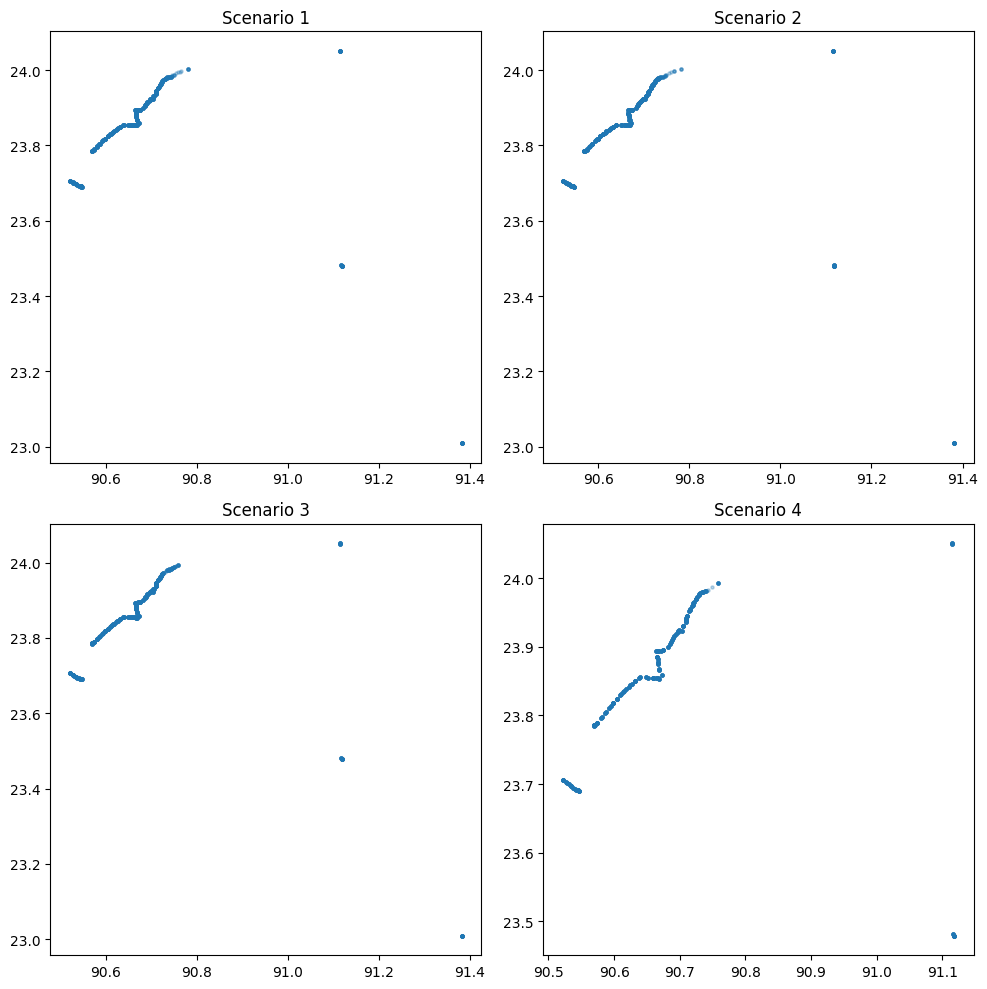

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for i, s in enumerate(scenarios):
    ax = axes[i//2, i%2]
    df = hotspots_data[s]

    ax.scatter(df['lon'], df['lat'], s=5, alpha=0.3)
    ax.set_title(f"Scenario {s}")

plt.style.use('default')

plt.tight_layout()
plt.show()

In [30]:
scenarios = [1, 2, 3, 4]
reps = range(1, 11)

vulnerability_data = {}

for s in scenarios:
    dfs = []
    for r in reps:
        file = f"scenario{s}_rep{r}_vulnerability.csv"
        df = load_and_merge(file)
        df['rep'] = r
        dfs.append(df)

    vulnerability_data[s] = pd.concat(dfs, ignore_index=True)

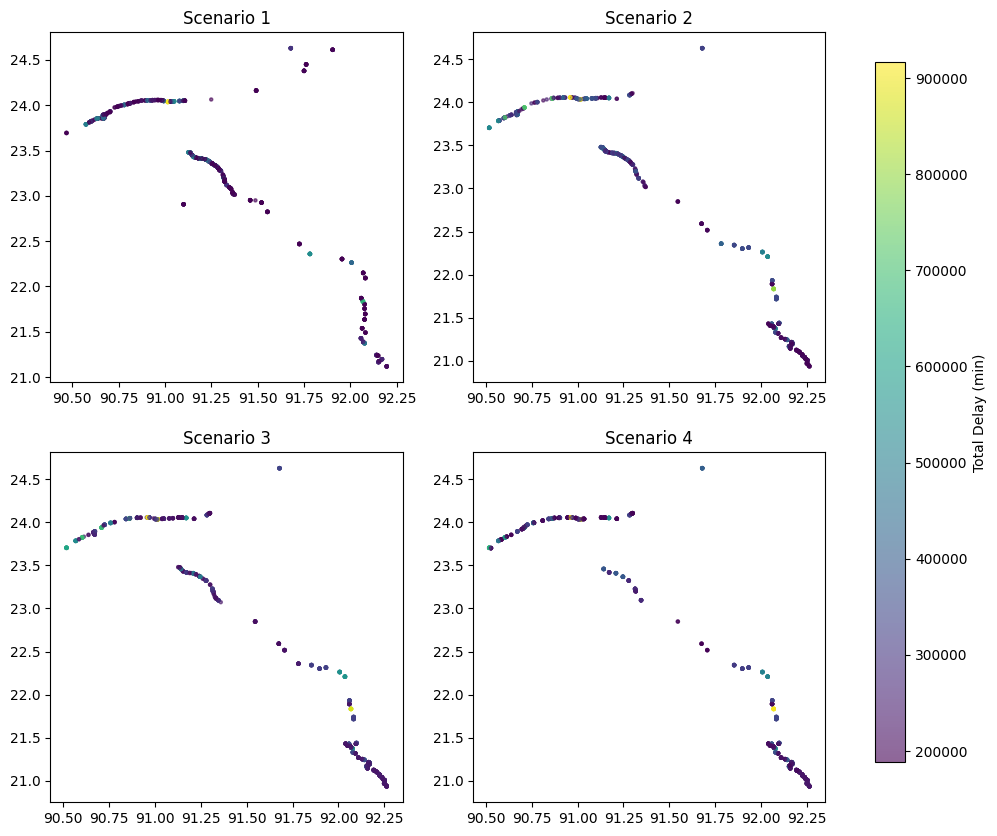

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for i, s in enumerate(scenarios):
    ax = axes[i//2, i%2]
    df = vulnerability_data[s]

    sc = ax.scatter(
        df['lon'],
        df['lat'],
        c=df['total_delay_min'],
        s=5,
        alpha=0.6
    )

    ax.set_title(f"Scenario {s}")


cbar_ax = fig.add_axes([0.95, 0.15, 0.03, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label("Total Delay (min)")

plt.style.use('default')

plt.savefig("vul_heatmaps.png")

plt.show()